# *Laboratório IV - Processamento Digital de Imagens -  Prof. Dr. Cassio Vinhal*
## Filtros Lineares
Atividade desenvolvida para obtenção de nota parcial da disciplina de PDI - 2026.1.


## Parte I: Suavização com filtro de tamanho arbitrário
Nessa primeira parte, faremos a suavização de uma imagem ruidosa com filtragem espacial.

In [ ]:
import numpy as np

# filtro espacial c/ kernel fixo
def spatialFilter(IMAGE):
    # kernel H
    H = np.array([
        [0,0,1,1,1,0,0],
        [0,1,1,1,1,1,0],
        [1,1,1,1,1,1,1],
        [0,1,1,1,1,1,0],
        [0,0,1,1,1,0,0]
    ], dtype=float)

    S = 1.0 / 23.0  # normalizacao

    M, N = IMAGE.shape

    K = H.shape[1] // 2  # largura/2
    L = H.shape[0] // 2  # altura/2

    # copia da img
    OUTPUT = IMAGE.copy()

    for U in range(K, M - K):
        for V in range(L, N - L):
            SUM = 0.0

            for I in range(-K, K + 1):
                for J in range(-L, L + 1):
                    P = IMAGE[U + I, V + J]
                    C = H[J + L, I + K]
                    SUM += C * P

            Q = int(round(S * SUM))

            # clamp
            Q = max(0, min(255, Q))

            OUTPUT[U, V] = Q

    return OUTPUT


Agora faremos a utilização de uma imagem ruidosa para realizar a suavização, usando máscaras/kernels box e gaussianos.

processando 5x5 ...
processando 9x9 ...
processando 11x11 ...
processando 15x15 ...
processando 21x21 ...
processando 25x25 ...
processando 31x31 ...
processando 35x35 ...
filtragem concluida!


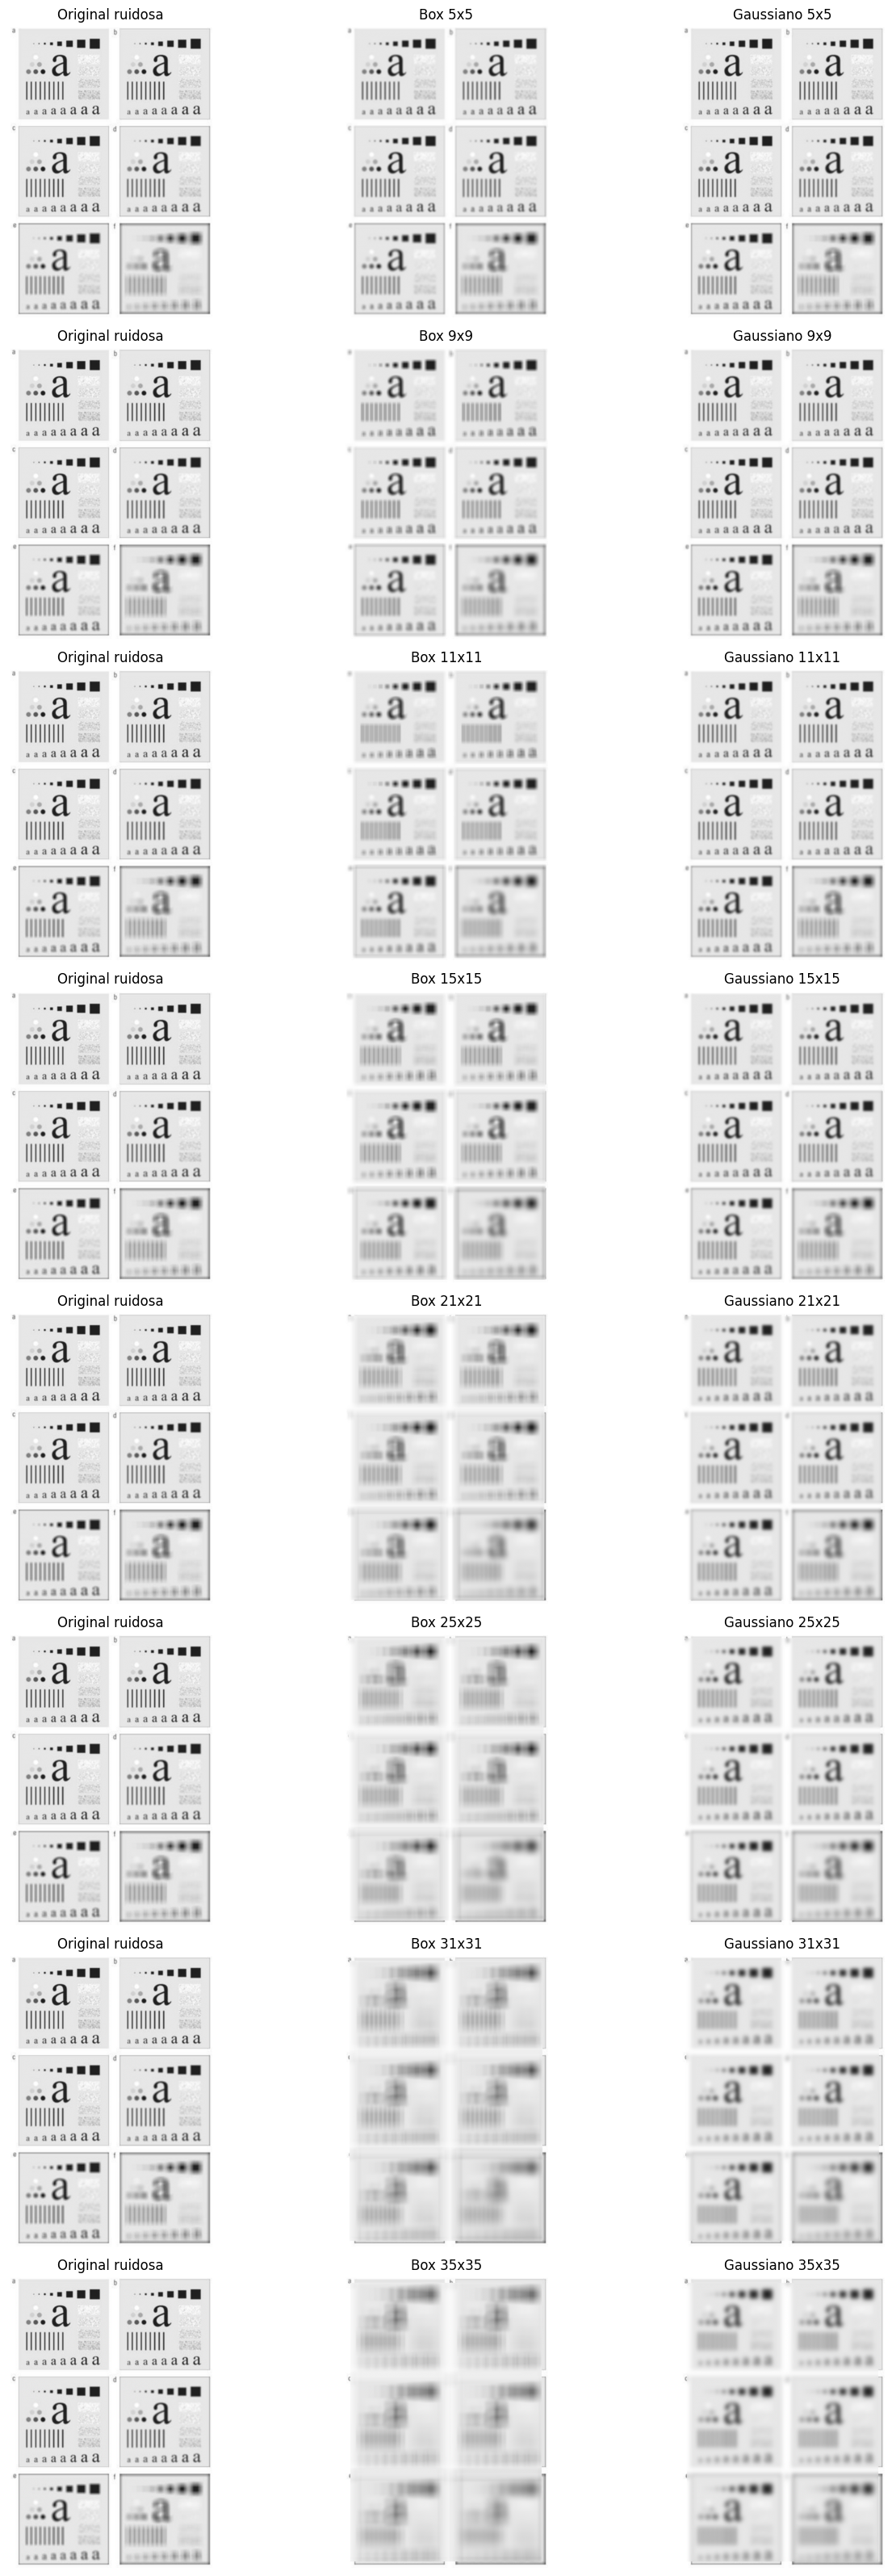


Exemplos de kernels gaussianos (pesos inteiros)

Kernel Gaussiano 5x5 - fator de escala: 1/22639
[[   1   29   90   29    1]
 [  29  854 2631  854   29]
 [  90 2631 8103 2631   90]
 [  29  854 2631  854   29]
 [   1   29   90   29    1]]

Kernel Gaussiano 9x9 - fator de escala: 1/90415
[[   1    7   29   68   90   68   29    7    1]
 [   7   51  209  487  645  487  209   51    7]
 [  29  209  854 1986 2631 1986  854  209   29]
 [  68  487 1986 4617 6117 4617 1986  487   68]
 [  90  645 2631 6117 8103 6117 2631  645   90]
 [  68  487 1986 4617 6117 4617 1986  487   68]
 [  29  209  854 1986 2631 1986  854  209   29]
 [   7   51  209  487  645  487  209   51    7]
 [   1    7   29   68   90   68   29    7    1]]



In [3]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# loadango a img ruidosa
NOISY_IMG = np.array(Image.open('IMG_RUIDOSA.png').convert('L'), dtype=float)

# def de filtragem generica
def spatialFilter(IMAGE, H, S):
    M, N = IMAGE.shape
    K = H.shape[1] // 2
    L = H.shape[0] // 2
    OUTPUT = IMAGE.copy()

    for U in range(L, M - L):
        for V in range(K, N - K):
            SUM = 0.0
            for I in range(-L, L + 1):
                for J in range(-K, K + 1):
                    SUM += H[I + L, J + K] * IMAGE[U + I, V + J]
            Q = int(round(S * SUM))
            OUTPUT[U, V] = max(0, min(255, Q))

    return OUTPUT

# gerando kernel box
def generateBoxKernel(SIZE):
    H = np.ones((SIZE, SIZE), dtype=float)
    S = 1.0 / H.sum()
    return H, S

# gerando kernel gaussiano c/ pesos inteiros
def generateGaussianKernel(SIZE):
    CENTER = SIZE // 2
    SIGMA = CENTER / 3.0

    # amostrando gaussiana continua
    AX = np.arange(SIZE) - CENTER
    XX, YY = np.meshgrid(AX, AX)
    H_FLOAT = np.exp(-(XX**2 + YY**2) / (2.0 * SIGMA**2))

    # normalizando p/ pesos inteiros
    H_FLOAT = H_FLOAT / H_FLOAT.min()
    H_INT = np.round(H_FLOAT).astype(int)

    S = 1.0 / H_INT.sum()
    return H_INT.astype(float), S

# tamanhos dos kernels
SIZES = [5, 9, 11, 15, 21, 25, 31, 35]

# aplicando filtros e guardando resultados
BOX_RESULTS = {}
GAUSS_RESULTS = {}

for T in SIZES:
    print(f'processando {T}x{T} ...')

    H_BOX, S_BOX = generateBoxKernel(T)
    BOX_RESULTS[T] = spatialFilter(NOISY_IMG, H_BOX, S_BOX)

    H_GAUSS, S_GAUSS = generateGaussianKernel(T)
    GAUSS_RESULTS[T] = spatialFilter(NOISY_IMG, H_GAUSS, S_GAUSS)

print('filtragem concluida!')

# plotando resultados
N = len(SIZES)
FIG, AXES = plt.subplots(N, 3, figsize=(14, 4 * N))

for IDX, T in enumerate(SIZES):
    # img original ruidosa
    AXES[IDX, 0].imshow(NOISY_IMG, cmap='gray', vmin=0, vmax=255)
    AXES[IDX, 0].set_title('Original ruidosa')
    AXES[IDX, 0].axis('off')

    # box filter
    AXES[IDX, 1].imshow(BOX_RESULTS[T], cmap='gray', vmin=0, vmax=255)
    AXES[IDX, 1].set_title(f'Box {T}x{T}')
    AXES[IDX, 1].axis('off')

    # filtro gaussiano
    AXES[IDX, 2].imshow(GAUSS_RESULTS[T], cmap='gray', vmin=0, vmax=255)
    AXES[IDX, 2].set_title(f'Gaussiano {T}x{T}')
    AXES[IDX, 2].axis('off')

plt.tight_layout()
plt.savefig('resultados_suavizacao.png', dpi=150, bbox_inches='tight')
plt.show()

# printando exemplos de kernels gaussianos
print('\nExemplos de kernels gaussianos (pesos inteiros)\n')
for T in [5, 9]:
    H_G, S_G = generateGaussianKernel(T)
    print(f'Kernel Gaussiano {T}x{T} - fator de escala: 1/{int(H_G.sum())}')
    print(H_G.astype(int))
    print()


### Discussão dos resultados

Comparando visualmente os resultados, fica claro que ambos os filtros (box e gaussiano) conseguem reduzir o ruído da imagem, porém com comportamentos bem diferentes. O filtro box aplica pesos iguais pra todos os pixels da vizinhança, entao ele suaviza de forma uniforme, isso remove ruido, mas também borra bastante as bordas e detalhes finos da imagem. Já o filtro gaussiano da mais peso pros pixels centrais e menos pros pixels mais distantes, o que faz com que ele preserve melhor as bordas e transições, resultando numa imagem mais natural mesmo após a filtragem.

Conforme o tamanho da mascara aumenta, o efeito de suavização fica mais forte nos dois casos. Com kernels pequenos tipo 5x5, a redução de ruído eé sútil e os detalhes são bem preservados. Mas quando chegamos em kernels grandes tipo 31x31 ou 35x35, a imagem fica visivelmente borrada, o ruído some quase todo, porém muita informação de detalhe tambem se perde. Esse tradeoff entre redução de ruído e preservação de detalhes é o ponto central da escolha do tamanho do kernel.

Em termos de complexidade computacional, o custo cresce de forma quadrática com o tamanho do kernel. Para cada pixel da imagem, a convolução precisa fazer n x n multiplicações e somas, onde n é o lado do kernel. Então um kernel 5x5 faz 25 operações por pixel, enquanto um 35x35 faz 1225 operações, quase 50x mais. Isso torna kernels muito grandes impraticáveis dependendo do tamanho da imagem, e motiva o uso de técnicas como separabilidade do kernel gaussiano (que reduz de O(n^2) pra O(2n) por pixel).

O gráfico abaixo ilustra esse comportamento, mostrando como o número de operações por pixel e o tempo de processamento crescem com o tamanho do kernel.

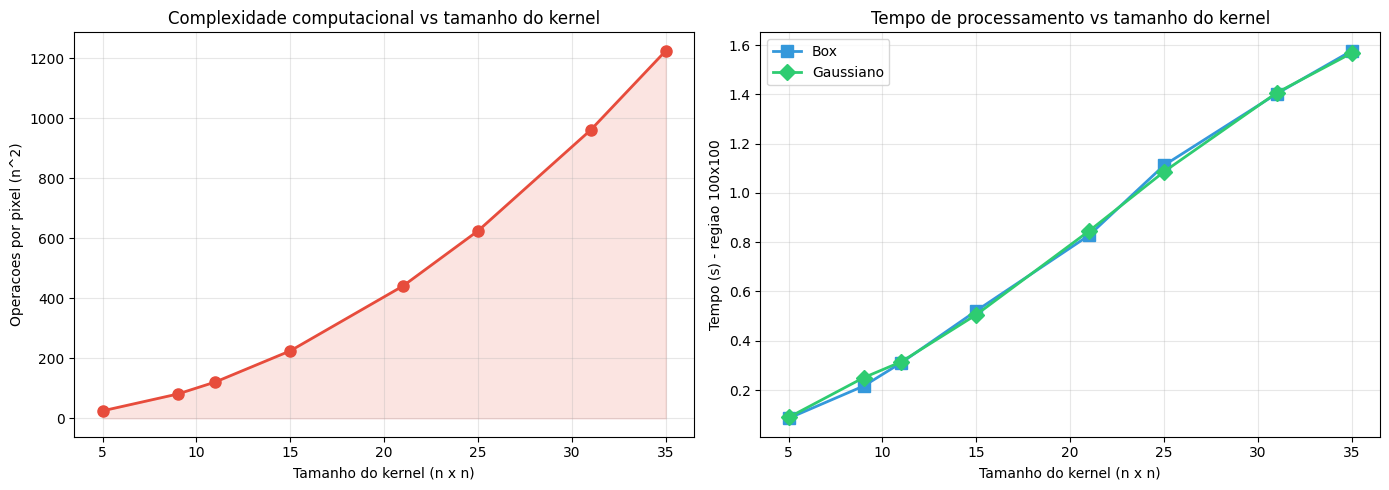

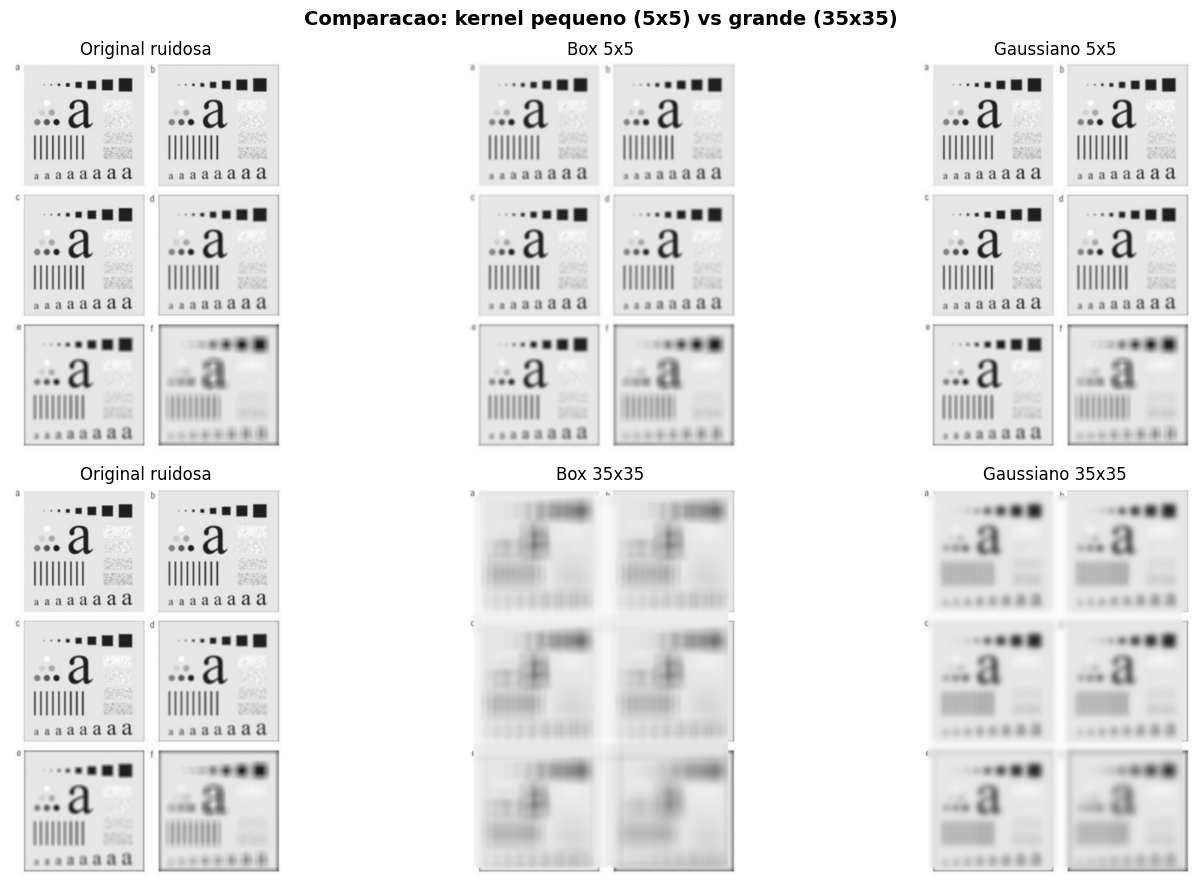

In [5]:
import time

# medindo tempo de execucao pra cada tamanho de kernel
TIMES_BOX = []
TIMES_GAUSS = []
OPS_PER_PIXEL = []

# usando uma regiao menor p/ medir tempo (senao demora muito)
SMALL_IMG = NOISY_IMG[:100, :100].copy()

for T in SIZES:
    OPS_PER_PIXEL.append(T * T)

    H_B, S_B = generateBoxKernel(T)
    START = time.time()
    spatialFilter(SMALL_IMG, H_B, S_B)
    TIMES_BOX.append(time.time() - START)

    H_G, S_G = generateGaussianKernel(T)
    START = time.time()
    spatialFilter(SMALL_IMG, H_G, S_G)
    TIMES_GAUSS.append(time.time() - START)

# grafico de complexidade
FIG, (AX1, AX2) = plt.subplots(1, 2, figsize=(14, 5))

# operacoes por pixel vs tamanho do kernel
AX1.plot(SIZES, OPS_PER_PIXEL, 'o-', color='#e74c3c', linewidth=2, markersize=8)
AX1.set_xlabel('Tamanho do kernel (n x n)')
AX1.set_ylabel('Operacoes por pixel (n^2)')
AX1.set_title('Complexidade computacional vs tamanho do kernel')
AX1.grid(True, alpha=0.3)
AX1.fill_between(SIZES, OPS_PER_PIXEL, alpha=0.15, color='#e74c3c')

# tempo de execucao vs tamanho do kernel
AX2.plot(SIZES, TIMES_BOX, 's-', color='#3498db', linewidth=2, markersize=8, label='Box')
AX2.plot(SIZES, TIMES_GAUSS, 'D-', color='#2ecc71', linewidth=2, markersize=8, label='Gaussiano')
AX2.set_xlabel('Tamanho do kernel (n x n)')
AX2.set_ylabel('Tempo (s) - regiao 100x100')
AX2.set_title('Tempo de processamento vs tamanho do kernel')
AX2.legend()
AX2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('grafico_complexidade.png', dpi=150, bbox_inches='tight')
plt.show()

# comparacao visual focada: menor vs maior kernel
FIG2, AXES2 = plt.subplots(2, 3, figsize=(15, 9))

# menor kernel (5x5)
AXES2[0, 0].imshow(NOISY_IMG, cmap='gray', vmin=0, vmax=255)
AXES2[0, 0].set_title('Original ruidosa')
AXES2[0, 0].axis('off')
AXES2[0, 1].imshow(BOX_RESULTS[5], cmap='gray', vmin=0, vmax=255)
AXES2[0, 1].set_title('Box 5x5')
AXES2[0, 1].axis('off')
AXES2[0, 2].imshow(GAUSS_RESULTS[5], cmap='gray', vmin=0, vmax=255)
AXES2[0, 2].set_title('Gaussiano 5x5')
AXES2[0, 2].axis('off')

# maior kernel (35x35)
AXES2[1, 0].imshow(NOISY_IMG, cmap='gray', vmin=0, vmax=255)
AXES2[1, 0].set_title('Original ruidosa')
AXES2[1, 0].axis('off')
AXES2[1, 1].imshow(BOX_RESULTS[35], cmap='gray', vmin=0, vmax=255)
AXES2[1, 1].set_title('Box 35x35')
AXES2[1, 1].axis('off')
AXES2[1, 2].imshow(GAUSS_RESULTS[35], cmap='gray', vmin=0, vmax=255)
AXES2[1, 2].set_title('Gaussiano 35x35')
AXES2[1, 2].axis('off')

plt.suptitle('Comparacao: kernel pequeno (5x5) vs grande (35x35)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('comparacao_visual.png', dpi=150, bbox_inches='tight')
plt.show()


## Parte II: Exercício do Gonzalez

Nessa segunda parte, faremos o Exercício 3.21 do Gonzalez, p.129. Reproduzindo os resultados, usando máscaras/kernels gaussianos e por fim, tratando das diferenças nos resultados.

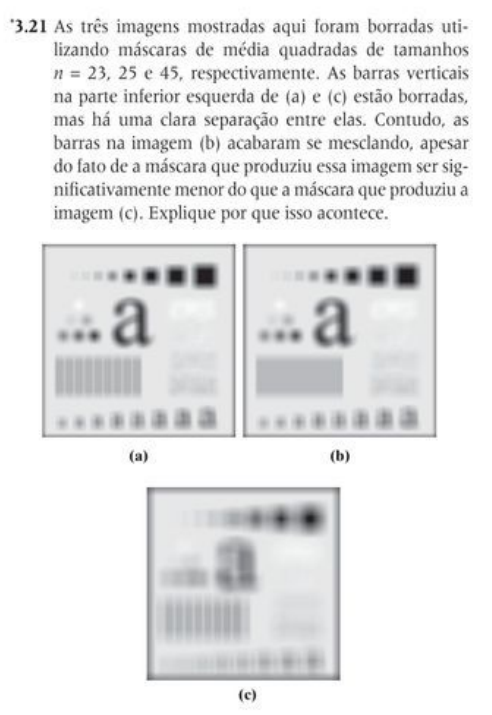

processando 23x23 ...
processando 25x25 ...
processando 45x45 ...
pronto!


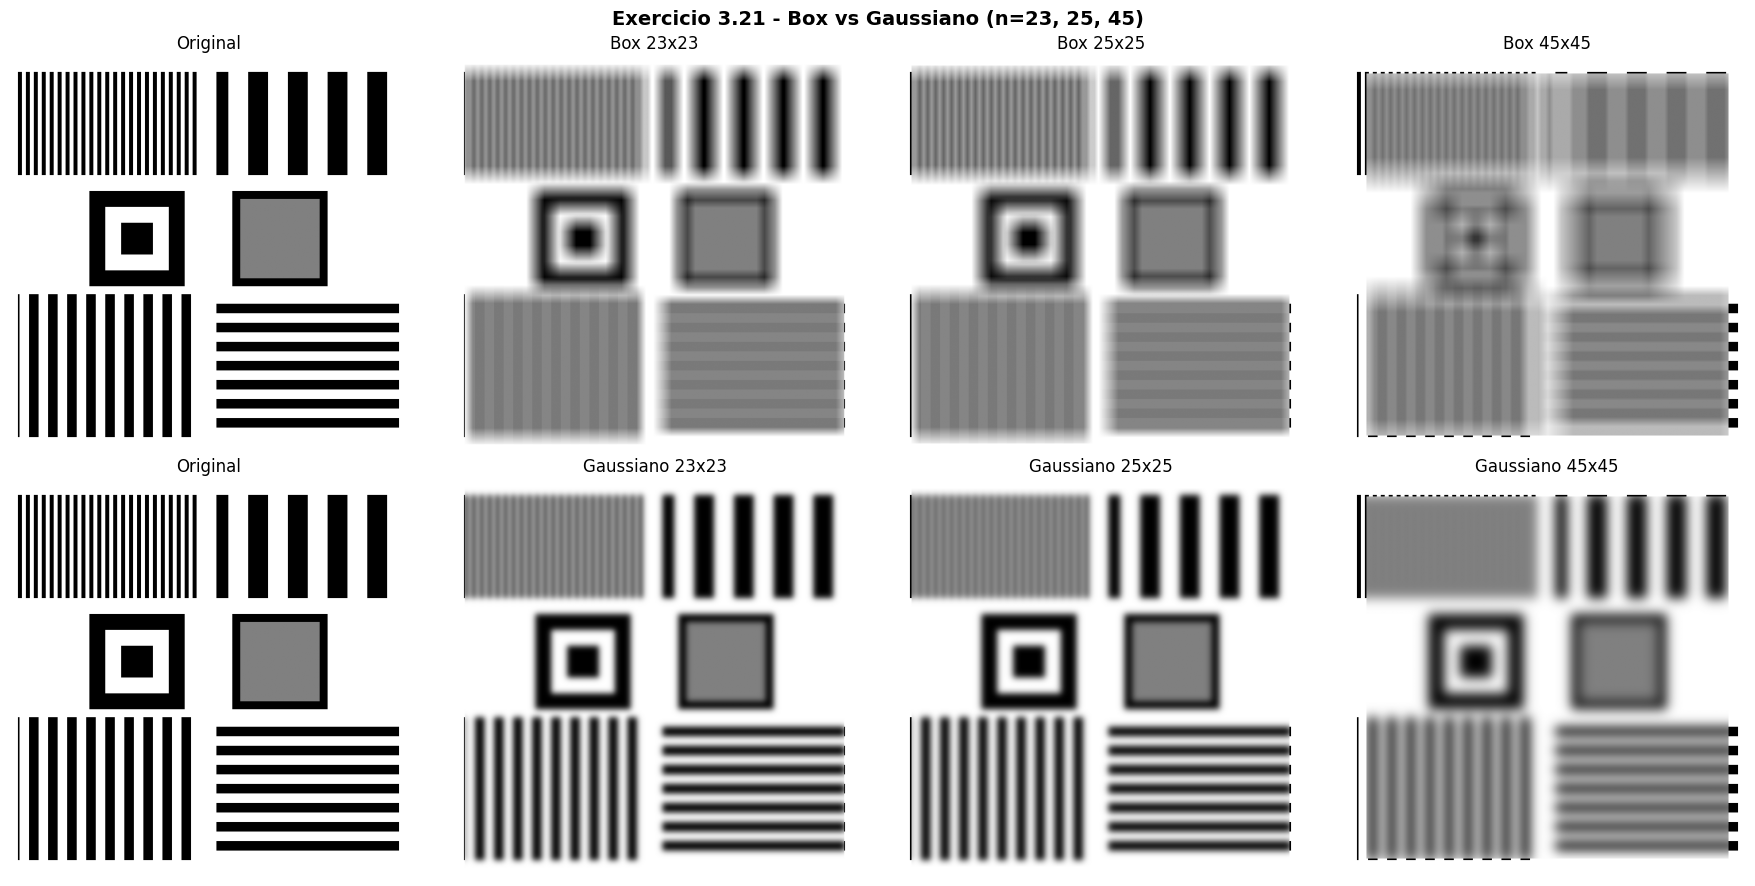

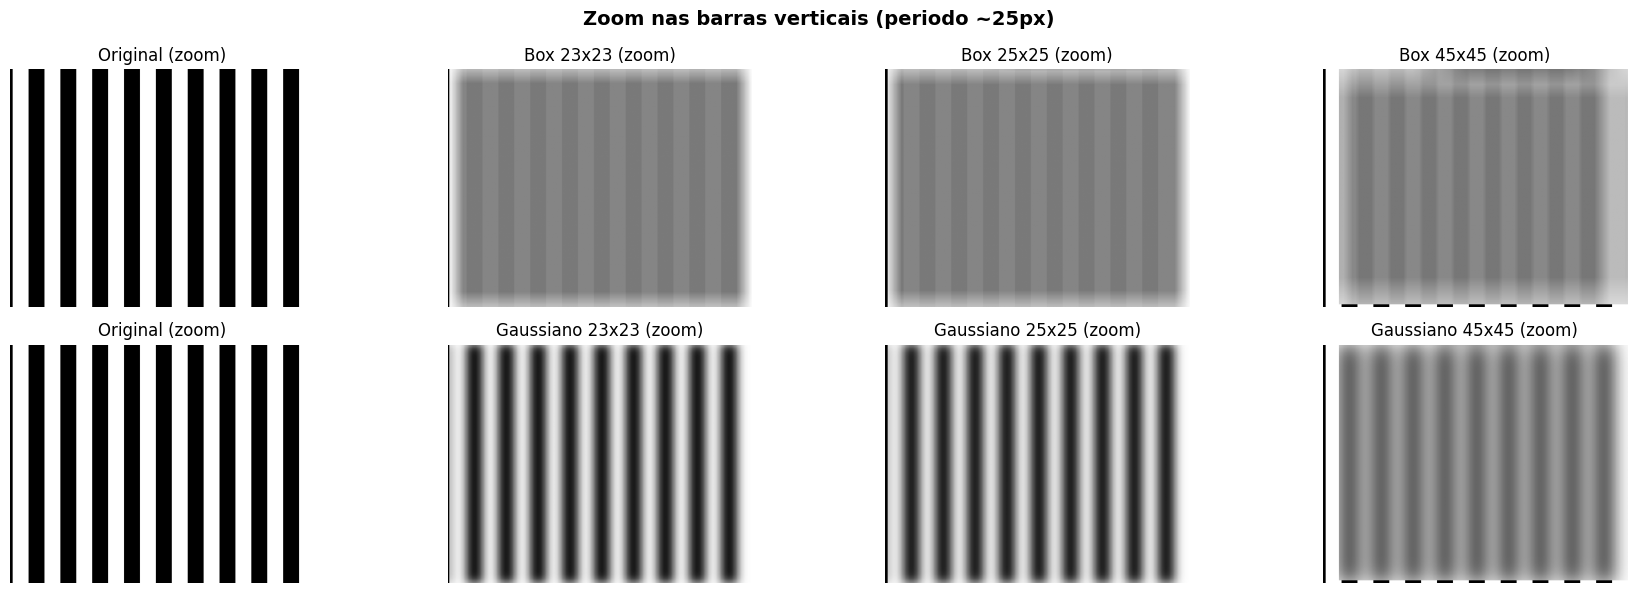

In [4]:
# gerando imagem de teste com barras verticais de diferentes frequencias
def generateTestChart(WIDTH=500, HEIGHT=500):
    IMG = np.zeros((HEIGHT, WIDTH), dtype=float)
    IMG[:] = 255  # fundo branco

    # barras verticais com periodo 25px (regiao inferior esquerda)
    BAR_PERIOD = 25
    for X in range(10, 240):
        if (X // (BAR_PERIOD // 2)) % 2 == 0:
            IMG[300:480, X] = 0

    # barras verticais com periodo 10px (regiao superior esquerda)
    for X in range(10, 240):
        if (X // 5) % 2 == 0:
            IMG[20:150, X] = 0

    # barras verticais com periodo 50px (regiao superior direita)
    for X in range(260, 490):
        if (X // 25) % 2 == 0:
            IMG[20:150, X] = 0

    # barras horizontais com periodo 25px (regiao inferior direita)
    for Y in range(300, 480):
        if (Y // (BAR_PERIOD // 2)) % 2 == 0:
            IMG[Y, 260:490] = 0

    # bloco central - quadrados de tamanhos variados
    IMG[170:290, 100:220] = 0
    IMG[190:270, 120:200] = 255
    IMG[210:250, 140:180] = 0

    IMG[170:290, 280:400] = 0
    IMG[180:280, 290:390] = 128

    return IMG

TEST_IMG = generateTestChart()

# tamanhos do exercicio 3.21
MASK_SIZES = [23, 25, 45]

# aplicando box e gaussiano p/ cada tamanho
BOX_321 = {}
GAUSS_321 = {}

for T in MASK_SIZES:
    print(f'processando {T}x{T} ...')
    H_B, S_B = generateBoxKernel(T)
    BOX_321[T] = spatialFilter(TEST_IMG, H_B, S_B)

    H_G, S_G = generateGaussianKernel(T)
    GAUSS_321[T] = spatialFilter(TEST_IMG, H_G, S_G)

print('pronto!')

# plotando resultados box filter
FIG, AXES = plt.subplots(2, 4, figsize=(18, 9))

# linha 1 - box
AXES[0, 0].imshow(TEST_IMG, cmap='gray', vmin=0, vmax=255)
AXES[0, 0].set_title('Original')
AXES[0, 0].axis('off')

for I, T in enumerate(MASK_SIZES):
    AXES[0, I+1].imshow(BOX_321[T], cmap='gray', vmin=0, vmax=255)
    AXES[0, I+1].set_title(f'Box {T}x{T}')
    AXES[0, I+1].axis('off')

# linha 2 - gaussiano
AXES[1, 0].imshow(TEST_IMG, cmap='gray', vmin=0, vmax=255)
AXES[1, 0].set_title('Original')
AXES[1, 0].axis('off')

for I, T in enumerate(MASK_SIZES):
    AXES[1, I+1].imshow(GAUSS_321[T], cmap='gray', vmin=0, vmax=255)
    AXES[1, I+1].set_title(f'Gaussiano {T}x{T}')
    AXES[1, I+1].axis('off')

AXES[0, 0].set_ylabel('Box Filter', fontsize=13, fontweight='bold')
AXES[1, 0].set_ylabel('Gaussiano', fontsize=13, fontweight='bold')

plt.suptitle('Exercicio 3.21 - Box vs Gaussiano (n=23, 25, 45)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('exercicio_321.png', dpi=150, bbox_inches='tight')
plt.show()

# zoom nas barras verticais (regiao inferior esquerda) p/ comparar
FIG2, AXES2 = plt.subplots(2, 4, figsize=(18, 6))

# recortando regiao das barras com periodo 25
Y1, Y2, X1, X2 = 300, 480, 10, 240

AXES2[0, 0].imshow(TEST_IMG[Y1:Y2, X1:X2], cmap='gray', vmin=0, vmax=255)
AXES2[0, 0].set_title('Original (zoom)')
AXES2[0, 0].axis('off')

for I, T in enumerate(MASK_SIZES):
    AXES2[0, I+1].imshow(BOX_321[T][Y1:Y2, X1:X2], cmap='gray', vmin=0, vmax=255)
    AXES2[0, I+1].set_title(f'Box {T}x{T} (zoom)')
    AXES2[0, I+1].axis('off')

AXES2[1, 0].imshow(TEST_IMG[Y1:Y2, X1:X2], cmap='gray', vmin=0, vmax=255)
AXES2[1, 0].set_title('Original (zoom)')
AXES2[1, 0].axis('off')

for I, T in enumerate(MASK_SIZES):
    AXES2[1, I+1].imshow(GAUSS_321[T][Y1:Y2, X1:X2], cmap='gray', vmin=0, vmax=255)
    AXES2[1, I+1].set_title(f'Gaussiano {T}x{T} (zoom)')
    AXES2[1, I+1].axis('off')

AXES2[0, 0].set_ylabel('Box', fontsize=13, fontweight='bold')
AXES2[1, 0].set_ylabel('Gaussiano', fontsize=13, fontweight='bold')

plt.suptitle('Zoom nas barras verticais (periodo ~25px)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('exercicio_321_zoom.png', dpi=150, bbox_inches='tight')
plt.show()


As barras verticais na imagem (b) se mesclam com a máscara 25×25 porque o tamanho da máscara coincide com o período espacial das barras. Quando o filtro box faz a média sobre exatamente um período completo de um padrão periódico, o resultado é uma constante, as barras simplesmente desaparecem. Isso é equivalente a dizer que, no domínio da frequência, a transformada do filtro box (função sinc) tem zeros em frequências f = k/n, e quando n=25, e, quando n = 25, um desses zeros cai exatamente na frequência das barras.

Já com n = 23, a máscara não cobre um período inteiro, então a média não cancela completamente as barras, sobra uma variação residual visível. Com n = 45, mesmo sendo uma máscara bem maior, ela cobre aproximadamente 1,8 períodos e, como não é um número inteiro de períodos, também não cancela totalmente. O resultado é que as barras ficam borradas, mas ainda distinguíveis.

Quanto ao filtro gaussiano: ele não apresenta esse mesmo comportamento. A transformada de Fourier da gaussiana é também uma gaussiana, que atenua as frequências de forma suave e monótona, sem os zeros abruptos da sinc. Isso significa que o gaussiano nunca elimina completamente uma frequência específica, ele apenas a atenua progressivamente. Por isso, com máscaras gaussianas de tamanhos 23, 25 e 45, as barras são suavizadas de forma mais previsível e proporcional ao tamanho da máscara, sem aquele efeito de cancelamento total que ocorre no box 25×25. O gaussiano é, portanto, um filtro mais “bem comportado” nesse sentido.

## Parte III: Diferentes tipos de padding

Nessa terceira parte, discutiremos sobre diferentes tipos de paddin no filtro com tamanho arbitrário de máscara.

Quando aplicamos um filtro espacial com máscara de tamanho arbitrário, os pixels próximos às bordas da imagem não têm vizinhança completa. O tratamento dessas bordas é o chamado padding, e existem várias estratégias.

**Zero padding** preenche as bordas com zeros (pixels pretos). É o mais simples de implementar, mas gera um artefato escuro visível nas bordas da imagem filtrada, já que os zeros puxam a média pra baixo. Quanto maior o kernel, mais larga essa faixa escura fica. É o método padrão em muitas implementações por ser rápido e direto.

**Replicate (repetição)** repete o valor do pixel mais próximo da borda. Produz resultados bem melhores que zero padding pois não introduz valores artificialmente baixos. A borda fica suavizada de forma mais natural, porém pode gerar um leve efeito de "plateau" onde os pixels de borda ficam todos com valores muito parecidos.

**Reflect (espelhamento)** espelha a imagem nas bordas. É geralmente considerado o melhor método, pois preserva a continuidade dos padrões próximos à borda. Não introduz descontinuidades e a transição na borda fica praticamente invisível. É o padrão em bibliotecas como OpenCV e scipy.

**Wrap (circular)** pega os pixels do lado oposto da imagem, como se ela fosse periódica. Funciona bem quando a imagem realmente tem características periódicas (tipo texturas repetitivas), mas na maioria dos casos gera artefatos estranhos nas bordas, pois normalmente os lados opostos da imagem não têm relação entre si.

**Sem padding (crop)** simplesmente não processa os pixels da borda, resultando numa imagem de saída menor. É o que nosso filtro original faz. Evita qualquer artefato, mas perde informação nas bordas.

Na prática, reflect e replicate são os mais usados pois produzem os melhores resultados visuais. O zero padding só é preferido quando a simplicidade é prioridade ou quando o escurecimento de borda não é problema (como em processamento intermediário de pipelines). O impacto do tipo de padding cresce com o tamanho do kernel: pra kernels pequenos a diferença é quase imperceptível, mas pra kernels grandes a escolha do padding faz diferença significativa.